## 09. Evaluacija i finalno poređenje modela

Ovaj notebook agrerira rezultate iz notebook-a 04, 06, 07 i 08 i vrši finalno poređenje sva 4 eksperimenta:

- **Eksperiment A**: SC + klasični ML (04)
- **Eksperiment B**: SC + Deep Learning / ESM-2 (06)
- **Eksperiment C**: MC + klasični ML (07)
- **Eksperiment D**: MC + Deep Learning / ESM-2 (08)

In [2]:
import os
import json
import joblib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn


from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, hamming_loss
)

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
MODEL_TAG = "t12_35M"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Koristi se uredjaj: {DEVICE}")

Koristi se uredjaj: cpu


### Konfiguracija i putanje

In [3]:
DATA_DIR = "../../data/processed/localization"
FEATURES_DIR = "../../data/features/localization"
MODELS_DIR = "../../data/models/localization"
METRICS_DIR = "../../results/metrics/localization"
FIGURES_DIR = "../../results/figures/localization"

os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

## Eksperiment A: SC + klasični ML (notebook 04)


In [4]:
sc_classical_results = pd.read_csv(os.path.join(METRICS_DIR, "sc_classical_modeling_results.csv"))
best_sc_classical = sc_classical_results.sort_values("CV F1 (weighted)", ascending=False).iloc[0]

print(f"Najbolja kombinacija: {best_sc_classical['Model']} + {best_sc_classical['Feature set']}")
print(f"Parametri: {best_sc_classical['Best params']}\n")

Najbolja kombinacija: SVM + AAC-CV+TFIDF-SVD
Parametri: {'C': 10, 'kernel': 'rbf'}



### Rekonstrukcija SC test raw obilježja

In [5]:
test_entries_df = pd.read_csv(os.path.join(FEATURES_DIR, "sc_test_entries.csv"))
entries_sc_test = test_entries_df["Entry"].values
y_sc_test = test_entries_df["label_encoded"].values

# LabelEncoder fitovan jednom u 03 (nema ponovnog fitovanja)
le = joblib.load(os.path.join(FEATURES_DIR, "sc_label_encoder.pkl"))

# Ucitavanje pojedinavnih tabela sa raw karakterisitama
aac_df = pd.read_csv(os.path.join(FEATURES_DIR, "aac_cv_features.csv"), index_col="Entry")
sc_test_seq_df = pd.read_csv(os.path.join(FEATURES_DIR, "sc_test_sequences_raw.csv"), index_col="Entry")
sc_test_ph_df = pd.read_csv(os.path.join(FEATURES_DIR, "sc_test_physchem_raw.csv"), index_col="Entry")

# Spajanje u jedinstveni raw DataFrame 
X_test_sc_raw = aac_df.join(sc_test_seq_df, how="inner").join(sc_test_ph_df, how="inner")
X_test_sc_raw = X_test_sc_raw.loc[entries_sc_test]

assert list(X_test_sc_raw.index) == list(entries_sc_test)
print(f"Test skup (SC): {X_test_sc_raw.shape} proteina")

Test skup (SC): (2122, 26) proteina


### Finalni classification report 

In [6]:
best_sc_model_path = os.path.join(
    MODELS_DIR, f"sc_{best_sc_classical['Model']}_{best_sc_classical['Feature set']}.pkl"
)

# Ucitava se čitav Pipeline (koji u sebi sadrži ColumnTransformer sa TF-IDF/SVD/Scaler i sam model)
best_sc_pipeline= joblib.load(best_sc_model_path)

# Predikcija se vrši direktno nad sirovim podacima (Pipeline brine o transformacijama)
y_pred_sc_classical= best_sc_pipeline.predict(X_test_sc_raw)


print(f"Eksperiment A: {best_sc_classical['Model']} + {best_sc_classical['Feature set']} \n")
print(classification_report(y_sc_test, y_pred_sc_classical, target_names=le.classes_))

Eksperiment A: SVM + AAC-CV+TFIDF-SVD 

               precision    recall  f1-score   support

Cell membrane       0.83      0.80      0.82       540
    Cytoplasm       0.61      0.69      0.65       496
Mitochondrion       0.51      0.60      0.55       178
      Nucleus       0.79      0.72      0.75       617
     Secreted       0.70      0.67      0.68       291

     accuracy                           0.71      2122
    macro avg       0.69      0.69      0.69      2122
 weighted avg       0.72      0.71      0.72      2122



### Matrica konfuzije

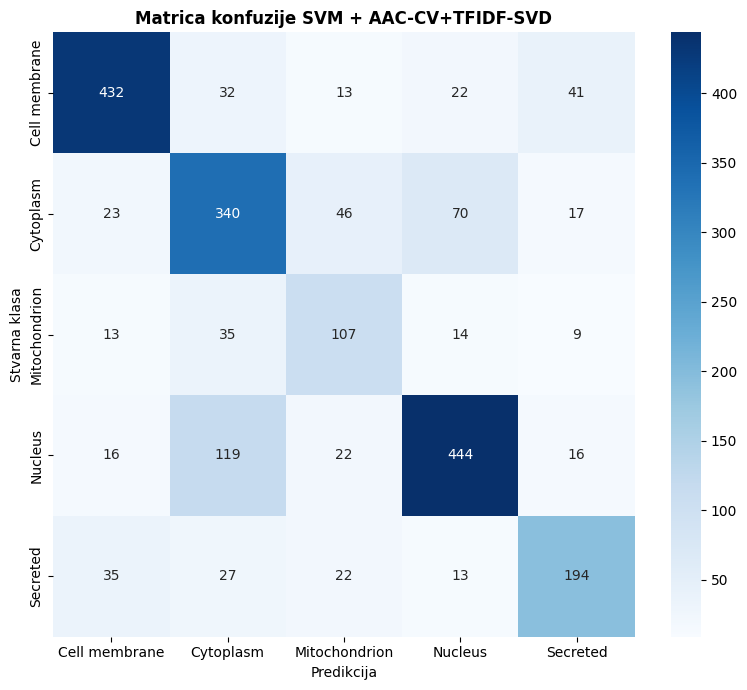

In [18]:
cm = confusion_matrix(y_sc_test, y_pred_sc_classical)

plt.figure(figsize=(8, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title(f"Matrica konfuzije {best_sc_classical['Model']} + {best_sc_classical['Feature set']}", fontweight="bold")
plt.xlabel("Predikcija")
plt.ylabel("Stvarna klasa")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_classical_sc_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

## Eksperiment B: SC + Deep Learning (notebook 06)

In [8]:
def build_mlp(input_dim, num_classes, hidden_dims, dropout):
    layers = []
    prev_dim = input_dim
    for h in hidden_dims:
        layers.extend([
            nn.Linear(prev_dim, h),
            nn.BatchNorm1d(h),
            nn.ReLU(),
            nn.Dropout(dropout)
        ])
        prev_dim = h
    layers.append(nn.Linear(prev_dim, num_classes))
    return nn.Sequential(*layers)

with open(os.path.join(MODELS_DIR, "sc_dl_mlp_config.json")) as f:
    sc_dl_config = json.load(f)

sc_dl_model = build_mlp(
    sc_dl_config["input_dim"], sc_dl_config["num_classes"],
    sc_dl_config["hidden_dims"], sc_dl_config["dropout"]
).to(DEVICE)

sc_dl_model.load_state_dict(
    torch.load(os.path.join(MODELS_DIR, "sc_dl_mlp_esm2.pt"), map_location=DEVICE)
)

sc_dl_model.eval()

# Scaler fitovan na SC train podskupu u 06 (nema ponovnog fitovanja)
sc_dl_scaler = joblib.load(os.path.join(MODELS_DIR, "sc_dl_embedding_scaler.pkl"))

embeddings_df = pd.read_csv(os.path.join(FEATURES_DIR, f"esm2_embeddings_{MODEL_TAG}.csv"), index_col="Entry")

X_sc_test_emb = embeddings_df.loc[entries_sc_test].values.astype(np.float32)
X_sc_test_emb_scaled = sc_dl_scaler.transform(X_sc_test_emb)

with torch.no_grad():
    logits_sc_dl = sc_dl_model(
        torch.tensor(X_sc_test_emb_scaled, dtype=torch.float32).to(DEVICE)
    )
    y_pred_sc_dl = torch.argmax(logits_sc_dl, dim=1).cpu().numpy()

print("Eksperiment B: MLP + ESM-2 embeddings\n")
print(classification_report(y_sc_test, y_pred_sc_dl, target_names=le.classes_))

Eksperiment B: MLP + ESM-2 embeddings

               precision    recall  f1-score   support

Cell membrane       0.91      0.88      0.89       540
    Cytoplasm       0.73      0.81      0.77       496
Mitochondrion       0.84      0.80      0.82       178
      Nucleus       0.89      0.84      0.87       617
     Secreted       0.87      0.90      0.88       291

     accuracy                           0.85      2122
    macro avg       0.85      0.84      0.85      2122
 weighted avg       0.85      0.85      0.85      2122



### Matrica konfuzije

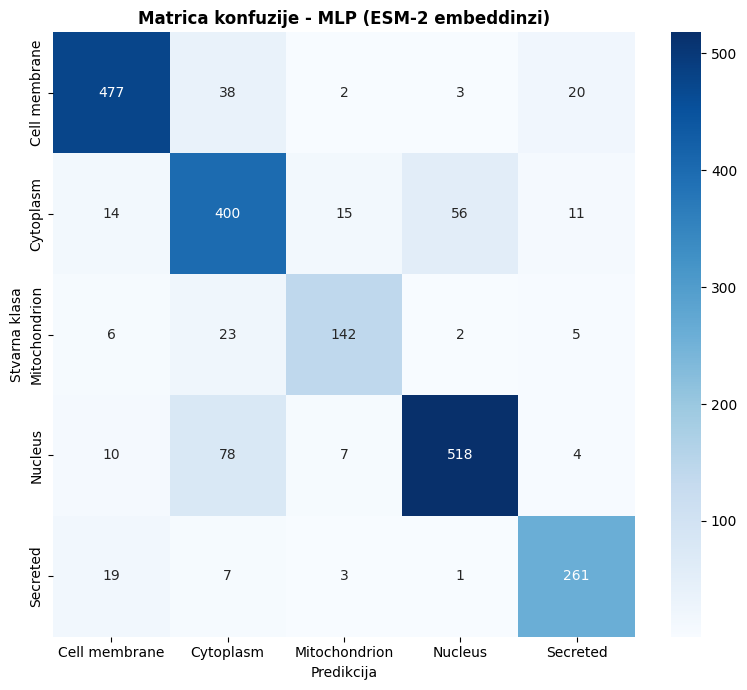

In [19]:
cm = confusion_matrix(y_sc_test, y_pred_sc_dl)

plt.figure(figsize=(8, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title("Matrica konfuzije - MLP (ESM-2 embeddinzi)", fontweight="bold")
plt.xlabel("Predikcija")
plt.ylabel("Stvarna klasa")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_dl_sc_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

## Eksperiment C: MC + klasični ML (notebook 07)

In [10]:
mc_classical_results = pd.read_csv(os.path.join(METRICS_DIR, "mc_classical_modeling_results.csv"))
best_mc_classical = mc_classical_results.sort_values("CV F1 micro", ascending=False).iloc[0]

print(f"Najbolja kombinacija: {best_mc_classical['Model']} + {best_mc_classical['Feature set']}")
print(f"Parametri: {best_mc_classical['Best params']}\n")

Najbolja kombinacija: SVM + AAC-CV+TFIDF-SVD
Parametri: {'model__estimator__C': 10, 'model__estimator__kernel': 'rbf'}



### Rekonstrukcija MC test obilježja

In [11]:
entries_mc_test = pd.read_csv(os.path.join(FEATURES_DIR, "mc_test_entries.csv"))["Entry"].values

# MultiLabelBinarizer fitovan jednom u 03 (nema ponovnog fitovanja)
mlb = joblib.load(os.path.join(FEATURES_DIR, "mc_label_binarizer.pkl"))
label_columns = list(mlb.classes_)

# Ucitavanje pojedinavnih tabela sa raw karakterisitama
aac_df = pd.read_csv(os.path.join(FEATURES_DIR, "aac_cv_features.csv"), index_col="Entry")
mc_test_seq_df = pd.read_csv(os.path.join(FEATURES_DIR, "mc_test_sequences_raw.csv"), index_col="Entry")
mc_test_ph_df = pd.read_csv(os.path.join(FEATURES_DIR, "mc_test_physchem_raw.csv"), index_col="Entry")

# Spajanje u jedinstveni raw DataFrame 
X_test_raw = aac_df.join(mc_test_seq_df, how="inner").join(mc_test_ph_df, how="inner")
X_test_raw = X_test_raw.loc[entries_mc_test]

mc_labels_df = pd.read_csv(os.path.join(FEATURES_DIR, "mc_labels.csv"), index_col="Entry")
y_mc_test = mc_labels_df.loc[entries_mc_test, label_columns].values

assert list(X_test_raw.index) == list(entries_mc_test)
print(f"Test skup (MC): {X_test_raw.shape} proteina")

Test skup (MC): (2858, 26) proteina


### Finalni classification report 

In [12]:
best_mc_model_path = os.path.join(
    MODELS_DIR, f"mc_{best_mc_classical['Model']}_{best_mc_classical['Feature set']}.pkl"
)

# Ucitava se čitav Pipeline (koji u sebi sadrži ColumnTransformer sa TF-IDF/SVD/Scaler i sam model)
best_mc_pipeline = joblib.load(best_mc_model_path)

# Predikcija se vrši direktno nad sirovim podacima (Pipeline brine o transformacijama)
y_pred_mc_classical= best_mc_pipeline.predict(X_test_raw)

print(f"Eksperiment C: {best_mc_classical['Model']} + {best_mc_classical['Feature set']} \n")
print(classification_report(y_mc_test, y_pred_mc_classical, target_names=label_columns, zero_division=0))

Eksperiment C: SVM + AAC-CV+TFIDF-SVD 

               precision    recall  f1-score   support

Cell membrane       0.77      0.70      0.73       820
    Cytoplasm       0.66      0.76      0.71      1164
Mitochondrion       0.52      0.46      0.49       273
      Nucleus       0.72      0.70      0.71      1147
     Secreted       0.65      0.64      0.65       426

    micro avg       0.69      0.69      0.69      3830
    macro avg       0.66      0.65      0.66      3830
 weighted avg       0.69      0.69      0.69      3830
  samples avg       0.69      0.73      0.68      3830



## Eksperiment D: MC + Deep Learning (notebook 08)

In [13]:
with open(os.path.join(MODELS_DIR, "mc_dl_mlp_config.json")) as f:
    mc_dl_config = json.load(f)

mc_dl_model = build_mlp(
    mc_dl_config["input_dim"], mc_dl_config["num_classes"],
    mc_dl_config["hidden_dims"], mc_dl_config["dropout"]
).to(DEVICE)

mc_dl_model.load_state_dict(
    torch.load(os.path.join(MODELS_DIR, "mc_dl_mlp_esm2.pt"), map_location=DEVICE)
)

mc_dl_model.eval()

# Scaler fitovan na MC train podskupu u 08 (nema ponovnog fitovanja)
mc_dl_scaler = joblib.load(os.path.join(MODELS_DIR, "mc_dl_embedding_scaler.pkl"))

X_mc_test_emb = embeddings_df.loc[entries_mc_test].values.astype(np.float32)
X_mc_test_emb_scaled = mc_dl_scaler.transform(X_mc_test_emb)

# Per-class pragovi optimizovani na val skupu u 08
thresholds_mc = np.array(mc_dl_config["thresholds"])

with torch.no_grad():
    logits_mc_dl = mc_dl_model(
        torch.tensor(X_mc_test_emb_scaled, dtype=torch.float32).to(DEVICE)
    )
    probs_mc_dl = torch.sigmoid(logits_mc_dl).cpu().numpy()
    y_pred_mc_dl = (probs_mc_dl >= thresholds_mc).astype(int)

print("Eksperiment D: MLP + ESM-2 embeddings\n")
print(classification_report(y_mc_test, y_pred_mc_dl, target_names=label_columns, zero_division=0))

Eksperiment D: MLP + ESM-2 embeddings

               precision    recall  f1-score   support

Cell membrane       0.86      0.79      0.82       820
    Cytoplasm       0.75      0.84      0.79      1164
Mitochondrion       0.73      0.61      0.67       273
      Nucleus       0.79      0.80      0.79      1147
     Secreted       0.87      0.81      0.84       426

    micro avg       0.79      0.80      0.80      3830
    macro avg       0.80      0.77      0.78      3830
 weighted avg       0.80      0.80      0.80      3830
  samples avg       0.83      0.85      0.81      3830



## Finalno poređenje sva četiri eksperimenta

In [14]:
sc_summary_df = pd.DataFrame([
    {
        "Eksperiment": "A: SC + Klasicni ML",
        "Konfiguracija": f"{best_sc_classical['Model']} + {best_sc_classical['Feature set']}",
        "Test Accuracy": accuracy_score(y_sc_test, y_pred_sc_classical),
        "Test F1 (weighted)": f1_score(y_sc_test, y_pred_sc_classical, average="weighted"),
    },
    {
        "Eksperiment": "B: SC + Deep Learning",
        "Konfiguracija": "MLP + ESM-2 embeddings",
        "Test Accuracy": accuracy_score(y_sc_test, y_pred_sc_dl),
        "Test F1 (weighted)": f1_score(y_sc_test, y_pred_sc_dl, average="weighted"),
    },
])

mc_summary_df = pd.DataFrame([
    {
        "Eksperiment": "C: MC + Klasicni ML",
        "Konfiguracija": f"{best_mc_classical['Model']} + {best_mc_classical['Feature set']}",
        "Test F1 micro": f1_score(y_mc_test, y_pred_mc_classical, average="micro", zero_division=0),
        "Test F1 macro": f1_score(y_mc_test, y_pred_mc_classical, average="macro", zero_division=0),
        "Test Subset Accuracy": accuracy_score(y_mc_test, y_pred_mc_classical),
        "Test Hamming Loss": hamming_loss(y_mc_test, y_pred_mc_classical),
    },
    {
        "Eksperiment": "D: MC + Deep Learning",
        "Konfiguracija": "MLP + ESM-2 embeddings",
        "Test F1 micro": f1_score(y_mc_test, y_pred_mc_dl, average="micro", zero_division=0),
        "Test F1 macro": f1_score(y_mc_test, y_pred_mc_dl, average="macro", zero_division=0),
        "Test Subset Accuracy": accuracy_score(y_mc_test, y_pred_mc_dl),
        "Test Hamming Loss": hamming_loss(y_mc_test, y_pred_mc_dl),
    },
])

print("SC eksperimenti (A vs. B):\n")
print(sc_summary_df.to_string(index=False))
print("\nMC eksperimenti (C vs. D):\n")
print(mc_summary_df.to_string(index=False))

SC eksperimenti (A vs. B):

          Eksperiment          Konfiguracija  Test Accuracy  Test F1 (weighted)
  A: SC + Klasicni ML SVM + AAC-CV+TFIDF-SVD       0.714892            0.717892
B: SC + Deep Learning MLP + ESM-2 embeddings       0.847314            0.848424

MC eksperimenti (C vs. D):

          Eksperiment          Konfiguracija  Test F1 micro  Test F1 macro  Test Subset Accuracy  Test Hamming Loss
  C: MC + Klasicni ML SVM + AAC-CV+TFIDF-SVD       0.690937       0.656408              0.444367           0.166340
D: MC + Deep Learning MLP + ESM-2 embeddings       0.796202       0.783799              0.593772           0.109657


### Vizualizacija: klasični ML vs. Deep Learning 

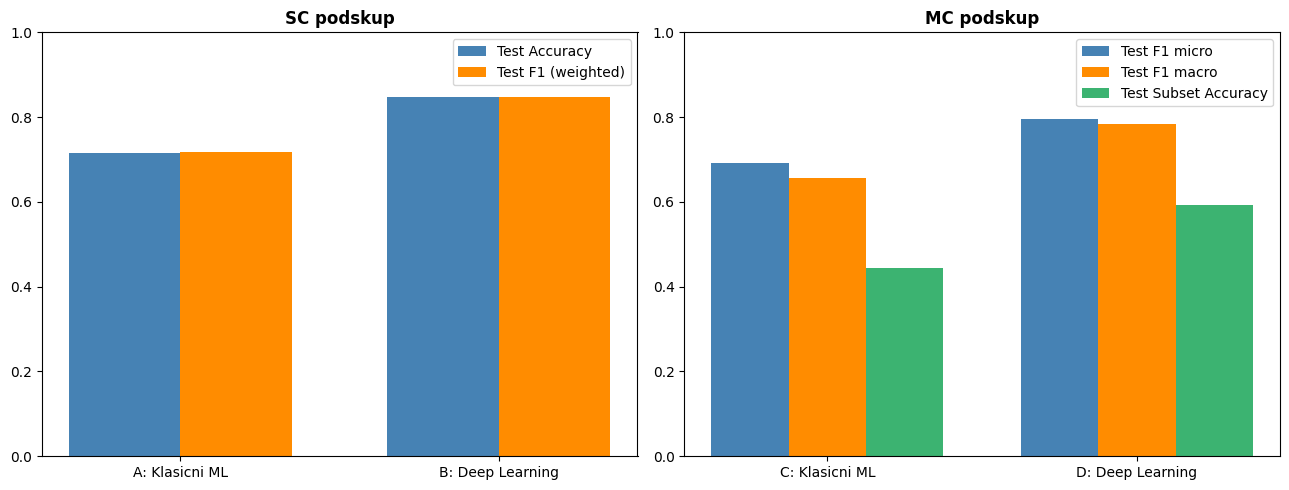

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# SC podskup
x_sc = np.arange(len(sc_summary_df))
width = 0.35
axes[0].bar(x_sc - width/2, sc_summary_df["Test Accuracy"], width, label="Test Accuracy", color="steelblue")
axes[0].bar(x_sc + width/2, sc_summary_df["Test F1 (weighted)"], width, label="Test F1 (weighted)", color="darkorange")
axes[0].set_xticks(x_sc)
axes[0].set_xticklabels(["A: Klasicni ML", "B: Deep Learning"])
axes[0].set_ylim(0, 1)
axes[0].set_title("SC podskup", fontweight="bold")
axes[0].legend()

# MC podskup
x_mc = np.arange(len(mc_summary_df))
width = 0.25
axes[1].bar(x_mc - width, mc_summary_df["Test F1 micro"], width, label="Test F1 micro", color="steelblue")
axes[1].bar(x_mc, mc_summary_df["Test F1 macro"], width, label="Test F1 macro", color="darkorange")
axes[1].bar(x_mc + width, mc_summary_df["Test Subset Accuracy"], width, label="Test Subset Accuracy", color="mediumseagreen")
axes[1].set_xticks(x_mc)
axes[1].set_xticklabels(["C: Klasicni ML", "D: Deep Learning"])
axes[1].set_ylim(0, 1)
axes[1].set_title("MC podskup", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_final_comparison_all_experiments.png"), dpi=300, bbox_inches="tight")
plt.show()

### Overfitting gap kroz sva četiri eksperimenta

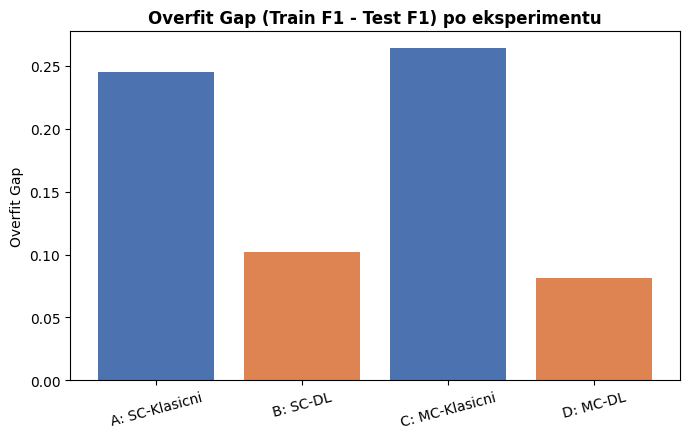

   Eksperiment  Overfit Gap (F1)
A: SC-Klasicni          0.244973
      B: SC-DL          0.102199
C: MC-Klasicni          0.264280
      D: MC-DL          0.081141


In [16]:
overfit_gap_df = pd.DataFrame([
    {"Eksperiment": "A: SC-Klasicni", "Overfit Gap (F1)": best_sc_classical["Train F1 (weighted)"] - best_sc_classical["Test F1 (weighted)"]},
    {"Eksperiment": "B: SC-DL", "Overfit Gap (F1)": pd.read_csv(os.path.join(METRICS_DIR, "sc_dl_modeling_results.csv"))["Overfit Gap (F1)"].iloc[0]},
    {"Eksperiment": "C: MC-Klasicni", "Overfit Gap (F1)": best_mc_classical["Train F1 micro"] - best_mc_classical["Test F1 micro"]},
    {"Eksperiment": "D: MC-DL", "Overfit Gap (F1)": pd.read_csv(os.path.join(METRICS_DIR, "mc_dl_modeling_results.csv"))["Overfit Gap (F1 micro)"].iloc[0]},
])

plt.figure(figsize=(7, 4.5))
colors = ["#4C72B0", "#DD8452", "#4C72B0", "#DD8452"]
plt.bar(overfit_gap_df["Eksperiment"], overfit_gap_df["Overfit Gap (F1)"], color=colors)
plt.title("Overfit Gap (Train F1 - Test F1) po eksperimentu", fontweight="bold")
plt.ylabel("Overfit Gap")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_overfit_gap_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

print(overfit_gap_df.to_string(index=False))

### Čuvanje finalnog sažetka rezultata

In [17]:
sc_summary_df.to_csv(os.path.join(METRICS_DIR, "final_summary_sc.csv"), index=False)
mc_summary_df.to_csv(os.path.join(METRICS_DIR, "final_summary_mc.csv"), index=False)
overfit_gap_df.to_csv(os.path.join(METRICS_DIR, "final_summary_overfit_gap.csv"), index=False)

print("Finalni rezultati su sacuvani.")

Finalni rezultati su sacuvani.
